<center>
    <img src="https://rockborne.com/wp-content/uploads/2021/07/LandingPage-Header-RED-CENTRE.jpg" width="900" alt="logo"  />
</center>

# Practical Pandas: Working with a Real Database (Coach Version)

## About this notebook
This practical lets you put into practice everything from the **Pandas Walkthrough**, this time on a real, multi-table database rather than a single tidy file. You will move through short, focused exercises that gradually build on one another: exploring data, selecting and sorting, filtering, creating columns, aggregating with `groupby`, and joining tables together. The final exercises pull all of these skills into a couple of genuine business questions.

## About the exercises
Each exercise is made of three cells:

1. **The question** (a markdown cell like this one).
2. **`# Your turn`**: an empty code cell for you to attempt the solution.
3. **`# Coach answer`**: the worked solution with correct code.

Try each one yourself before looking at the answer. Later exercises reuse variables created in earlier ones, so work through them in order.

> **Coach note:** this is the *coach version*, so every answer is filled in and the notebook runs top-to-bottom with `Run All`. To produce the learner version, delete the `# Coach answer` cells.

## About the database: Pagila
We use **Pagila**, a well-known sample database for a fictional DVD-rental company. Its CSV files live one folder up from this notebook, in [`../datasets/pagila_csv/`](../datasets/pagila_csv/). Pagila spreads its data across many tables (customers, addresses, payments, films, actors, categories, inventory and more). A core skill you will practise is reading the **Entity-Relationship (ER) diagram** below to work out *which* tables you need and *how* they connect.

## Reference: the Pagila ER diagram
Keep this diagram handy. Several exercises ask you to decide which tables to join based on it.

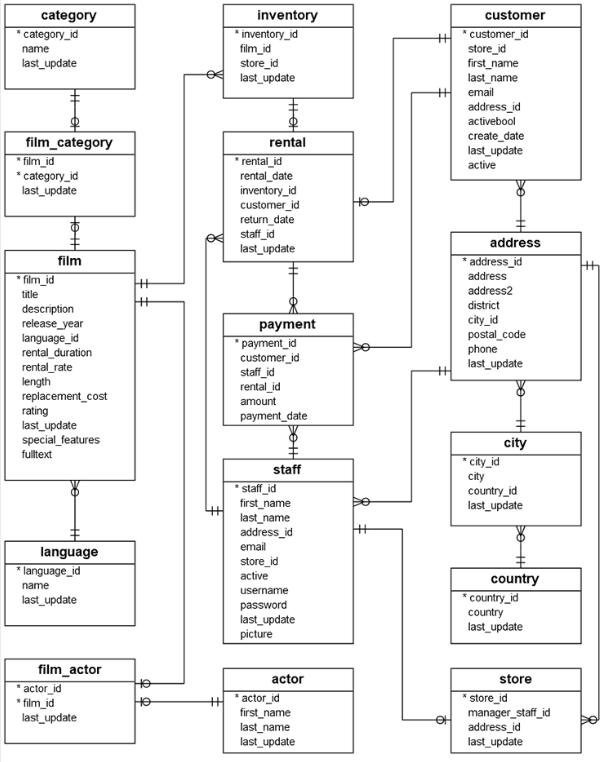

---
# Part 0: Setup and loading the data

First we import the libraries we need. Because the data sits **one directory above** this notebook, every path starts with `../` (go up one level), followed by `datasets/pagila_csv/`.

In [1]:
import pandas as pd
import glob
from config import pagila_datasets

In [ ]:
##Local files
# Path to the Pagila CSV folder (one level up from this notebook)
#DATA = '../datasets/pagila_csv/'

# Load a few dimension tables we'll reuse throughout
#customer = pd.read_csv(DATA + 'customer.csv')
#address  = pd.read_csv(DATA + 'address.csv')
#city     = pd.read_csv(DATA + 'city.csv')
#country  = pd.read_csv(DATA + 'country.csv')

In [ ]:
##Databricks version: 
"""
customer = (
    spark.read.csv(
        pagila_datasets["customer"],
        header=True,
        inferSchema=True
    )
).toPandas()

address = (
    spark.read.csv(
        pagila_datasets["address"],
        header=True,
        inferSchema=True
    )
).toPandas()

city = (
    spark.read.csv(
        pagila_datasets["city"],
        header=True,
        inferSchema=True
    )
).toPandas()

country = (
    spark.read.csv(
        pagila_datasets["country"],
        header=True,
        inferSchema=True
    )
).toPandas()
"""

In [ ]:
##Databricks shorter version: 

"""
def load_s3_to_pandas(path):
    return (
        spark.read.csv(
            path,
            header=True,
            inferSchema=True
        )
    ).toPandas()

customer = load_s3_to_pandas(pagila_datasets["customer"])
address  = load_s3_to_pandas(pagila_datasets["address"])
city     = load_s3_to_pandas(pagila_datasets["city"])
country  = load_s3_to_pandas(pagila_datasets["country"])

"""

In [2]:
##From S3
# Load a few dimension tables we'll reuse throughout
customer = pd.read_csv(pagila_datasets["customer"])
address  = pd.read_csv(pagila_datasets["address"])
city     = pd.read_csv(pagila_datasets["city"])
country  = pd.read_csv(pagila_datasets["country"])

In [3]:
len(customer), len(address), len(city), len(country)

(599, 603, 600, 109)

### Exercise 0: Build the sales table by union

The sales (payment) data is **split across 7 monthly files** (`payment_p2022_01.csv` ... `payment_p2022_07.csv`). Stack them on top of each other (a *union* of rows) into a single DataFrame called `payment`, then check its shape.

> *Hint: `glob.glob()` finds files matching a pattern; `pd.concat([...])` unions a list of DataFrames. Use `ignore_index=True` so the row index is renumbered cleanly.*

In [ ]:
# Your turn. Write your solution here:


In [ ]:
# Coach answer
# Local files
#files = sorted(glob.glob(DATA + 'payment_p2022_0*.csv'))
#payment = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
#print(payment.shape)
#payment.head()

(16049, 6)


,payment_id,customer_id,staff_id,rental_id,amount,payment_date
0,16051,269,1,98,0.99,2022-01-29 01:58:52.222594+00:00
1,16065,274,1,147,2.99,2022-01-25 12:14:16.895377+00:00
2,16109,297,2,143,0.99,2022-01-28 00:49:49.128218+00:00
3,16195,344,2,157,2.99,2022-01-31 05:58:51.176578+00:00
4,16202,348,2,821,0.99,2022-01-26 16:52:41.359433+00:00


In [ ]:

# Coach answer
#Froms3
payment = pd.concat([pd.read_csv(f) for f in pagila_datasets["payments"].values()], ignore_index=True)
len(payment)

16049

---
# Part 1: Explore the data
Before analysing anything, get a feel for what each table contains.

### Exercise 1.1: First look at the payments

Show the first few rows of `payment`, then list its column names.

In [78]:
# Your turn. Write your solution here:


In [79]:
# Coach answer
display(payment.head())
print(payment.columns.tolist())

,payment_id,customer_id,staff_id,rental_id,amount,payment_date
0,16051,269,1,98,0.99,2022-01-29 01:58:52.222594+00:00
1,16065,274,1,147,2.99,2022-01-25 12:14:16.895377+00:00
2,16109,297,2,143,0.99,2022-01-28 00:49:49.128218+00:00
3,16195,344,2,157,2.99,2022-01-31 05:58:51.176578+00:00
4,16202,348,2,821,0.99,2022-01-26 16:52:41.359433+00:00


['payment_id', 'customer_id', 'staff_id', 'rental_id', 'amount', 'payment_date']


### Exercise 1.2: Column types

What **data type** is each column in `payment`? In particular, is `payment_date` stored as a date or as text? Is `amount` numeric?

> *Hint: `.info()` shows the dtype of every column at once.*

In [80]:
# Your turn. Write your solution here:


In [81]:
# Coach answer
payment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16049 entries, 0 to 16048
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   payment_id    16049 non-null  int64  
 1   customer_id   16049 non-null  int64  
 2   staff_id      16049 non-null  int64  
 3   rental_id     16049 non-null  int64  
 4   amount        16049 non-null  float64
 5   payment_date  16049 non-null  object 
dtypes: float64(1), int64(4), object(1)
memory usage: 752.4+ KB


### Exercise 1.3: Summary statistics

Use a single method to get the count, mean, min and max of the numeric columns in `payment`. What is the largest single payment?

> *Hint: `.describe()` summarises the numeric columns.*

In [82]:
# Your turn. Write your solution here:


In [83]:
# Coach answer
payment.describe()

,payment_id,customer_id,staff_id,rental_id,amount
count,16049.00000,16049.000000,16049.000000,16049.000000,16049.000000
mean,24074.00000,297.162689,1.497975,8024.301514,4.200667
std,4633.09157,172.468100,0.500011,4632.452025,2.362994
min,16050.00000,1.000000,1.000000,1.000000,0.000000
25%,20062.00000,148.000000,1.000000,4015.000000,2.990000
50%,24074.00000,296.000000,1.000000,8023.000000,3.990000
75%,28086.00000,446.000000,2.000000,12036.000000,4.990000
max,32098.00000,599.000000,2.000000,16049.000000,11.990000


---
# Part 2: Selecting columns and sorting


### Exercise 2.1: Select two columns

Create a DataFrame with only the `customer_id` and `amount` columns from `payment`.

> *Hint: Selecting multiple columns needs a *list* of names inside the square brackets.*

In [84]:
# Your turn. Write your solution here:


In [85]:
# Coach answer
payment[['customer_id', 'amount']].head()

,customer_id,amount
0,269,0.99
1,274,2.99
2,297,0.99
3,344,2.99
4,348,0.99


### Exercise 2.2: Find the biggest payments

Sort `payment` by `amount` from highest to lowest and show the top 5 rows.

> *Hint: `sort_values(by=..., ascending=False)` sorts high to low.*

In [86]:
# Your turn. Write your solution here:


In [87]:
# Coach answer
payment.sort_values(by='amount', ascending=False).head()

,payment_id,customer_id,staff_id,rental_id,amount,payment_date
15558,28814,592,1,3973,11.99,2022-07-06 12:15:38.928947+00:00
1877,23757,116,2,14763,11.99,2022-02-11 03:52:25.634006+00:00
5288,28799,591,2,4383,11.99,2022-03-08 16:41:23.911522+00:00
3301,17055,196,2,106,11.99,2022-03-18 18:50:39.243747+00:00
15602,29136,13,2,8831,11.99,2022-07-22 16:15:40.797771+00:00


### Exercise 2.3: Sort customers alphabetically

Show customers sorted by `last_name` (A to Z).

In [88]:
# Your turn. Write your solution here:


In [89]:
# Coach answer
customer.sort_values(by='last_name').head()

,customer_id,store_id,first_name,last_name,email,address_id,activebool,create_date,last_update,active
504,505,1,RAFAEL,ABNEY,RAFAEL.ABNEY@sakilacustomer.org,510,True,2022-02-14,2022-02-15 09:57:20+00:00,1
503,504,1,NATHANIEL,ADAM,NATHANIEL.ADAM@sakilacustomer.org,509,True,2022-02-14,2022-02-15 09:57:20+00:00,1
35,36,2,KATHLEEN,ADAMS,KATHLEEN.ADAMS@sakilacustomer.org,40,True,2022-02-14,2022-02-15 09:57:20+00:00,1
95,96,1,DIANA,ALEXANDER,DIANA.ALEXANDER@sakilacustomer.org,100,True,2022-02-14,2022-02-15 09:57:20+00:00,1
469,470,1,GORDON,ALLARD,GORDON.ALLARD@sakilacustomer.org,475,True,2022-02-14,2022-02-15 09:57:20+00:00,1


---
# Part 3: Filtering rows


### Exercise 3.1: High-value payments

Select only the payments where `amount` is greater than 8.

> *Hint: Put a boolean condition inside the square brackets.*

In [90]:
# Your turn. Write your solution here:


In [91]:
# Coach answer
payment[payment['amount'] > 8].head()

,payment_id,customer_id,staff_id,rental_id,amount,payment_date
22,16518,515,2,187,8.99,2022-01-29 08:03:30.047386+00:00
54,17276,286,1,1690,8.99,2022-01-28 16:14:04.070713+00:00
65,17423,322,2,3413,8.99,2022-01-28 05:07:02.442022+00:00
78,17737,398,2,3141,9.99,2022-01-24 12:31:08.469382+00:00
137,18920,108,1,2061,8.99,2022-01-24 22:31:23.915378+00:00


### Exercise 3.2: Customers of a single store

Select the customers belonging to store 2.

In [92]:
# Your turn. Write your solution here:


In [93]:
# Coach answer
customer[customer['store_id'] == 2].head()

,customer_id,store_id,first_name,last_name,email,address_id,activebool,create_date,last_update,active
3,4,2,BARBARA,JONES,BARBARA.JONES@sakilacustomer.org,8,True,2022-02-14,2022-02-15 09:57:20+00:00,1
5,6,2,JENNIFER,DAVIS,JENNIFER.DAVIS@sakilacustomer.org,10,True,2022-02-14,2022-02-15 09:57:20+00:00,1
7,8,2,SUSAN,WILSON,SUSAN.WILSON@sakilacustomer.org,12,True,2022-02-14,2022-02-15 09:57:20+00:00,1
8,9,2,MARGARET,MOORE,MARGARET.MOORE@sakilacustomer.org,13,True,2022-02-14,2022-02-15 09:57:20+00:00,1
10,11,2,LISA,ANDERSON,LISA.ANDERSON@sakilacustomer.org,15,True,2022-02-14,2022-02-15 09:57:20+00:00,1


### Exercise 3.3: Combine two conditions

Select customers who belong to store 2 **and** are active (`active == 1`).

> *Hint: Combine conditions with `&` and wrap each one in parentheses.*

In [94]:
# Your turn. Write your solution here:


In [95]:
# Coach answer
customer[(customer['store_id'] == 2) & (customer['active'] == 1)].head()

,customer_id,store_id,first_name,last_name,email,address_id,activebool,create_date,last_update,active
3,4,2,BARBARA,JONES,BARBARA.JONES@sakilacustomer.org,8,True,2022-02-14,2022-02-15 09:57:20+00:00,1
5,6,2,JENNIFER,DAVIS,JENNIFER.DAVIS@sakilacustomer.org,10,True,2022-02-14,2022-02-15 09:57:20+00:00,1
7,8,2,SUSAN,WILSON,SUSAN.WILSON@sakilacustomer.org,12,True,2022-02-14,2022-02-15 09:57:20+00:00,1
8,9,2,MARGARET,MOORE,MARGARET.MOORE@sakilacustomer.org,13,True,2022-02-14,2022-02-15 09:57:20+00:00,1
10,11,2,LISA,ANDERSON,LISA.ANDERSON@sakilacustomer.org,15,True,2022-02-14,2022-02-15 09:57:20+00:00,1


### Exercise 3.4: Filter by a list of values

Select the payments made by customers with id 1, 2 or 3.

> *Hint: `.isin([...])` tests membership against a list, much tidier than chaining `|`.*

In [96]:
# Your turn. Write your solution here:


In [97]:
# Coach answer
payment[payment['customer_id'].isin([1, 2, 3])].head()

,payment_id,customer_id,staff_id,rental_id,amount,payment_date
29,16681,3,1,830,2.99,2022-01-23 17:24:52.109704+00:00
116,18506,3,1,2628,2.99,2022-01-26 01:58:25.925938+00:00
296,22701,2,2,15907,4.99,2022-01-24 08:17:41.922082+00:00
297,22708,3,1,15619,2.99,2022-01-30 00:44:18.250996+00:00
572,28999,1,1,7841,4.99,2022-01-29 13:03:02.267403+00:00


---
# Part 4: Creating columns


### Exercise 4.1: A full-name column

Add a new column `full_name` to `customer` that joins `first_name` and `last_name` with a space, for example `MARY SMITH`.

In [98]:
# Your turn. Write your solution here:


In [99]:
# Coach answer
customer['full_name'] = customer['first_name'] + ' ' + customer['last_name']
customer[['first_name', 'last_name', 'full_name']].head()

,first_name,last_name,full_name
0,MARY,SMITH,MARY SMITH
1,PATRICIA,JOHNSON,PATRICIA JOHNSON
2,LINDA,WILLIAMS,LINDA WILLIAMS
3,BARBARA,JONES,BARBARA JONES
4,ELIZABETH,BROWN,ELIZABETH BROWN


### Exercise 4.2: Bucket payments with `.apply()`

Write a function that labels an amount as `'small'` (below 3), `'medium'` (3 to 7) or `'large'` (above 7), then use `.apply()` to create a `size` column on `payment`.

> *Hint: Define a normal Python function, then call `payment['amount'].apply(your_function)`.*

In [100]:
# Your turn. Write your solution here:


In [101]:
# Coach answer
def payment_size(amount):
    if amount < 3:
        return 'small'
    elif amount <= 7:
        return 'medium'
    return 'large'

payment['size'] = payment['amount'].apply(payment_size)
payment['size'].value_counts()

size
medium    7331
small     7186
large     1532
Name: count, dtype: int64

---
# Part 5: Aggregating with `groupby`
This is the key skill for the analysis at the end of the notebook.

### Exercise 5.1: Total spent per customer

Group `payment` by `customer_id` and find the **total** amount each customer has spent.

In [102]:
# Your turn. Write your solution here:


In [103]:
# Coach answer
payment.groupby('customer_id')['amount'].sum().head()

customer_id
1    118.68
2    128.73
3    135.74
4     81.78
5    144.62
Name: amount, dtype: float64

### Exercise 5.2: Total sales per month

You combined all of the monthly sales into `payment` back in Exercise 0. Now that every month sits in one table, find the **total revenue** and the **number of payments** for each calendar month.

> *Hint: Convert `payment_date` with `pd.to_datetime(..., utc=True)`, pull out the month with `.dt.month`, then `groupby('month')` and aggregate.*

In [104]:
# Your turn. Write your solution here:


In [105]:
# Coach answer
payment['payment_date'] = pd.to_datetime(payment['payment_date'], utc=True)
payment['month'] = payment['payment_date'].dt.month
payment.groupby('month')['amount'].agg(['sum', 'count']).round(2)

,sum,count
month,,
1,3094.78,723
2,10164.97,2401
3,11413.86,2713
4,10759.52,2547
5,11347.28,2677
6,10923.45,2654
7,9712.65,2334


### Exercise 5.3: Sales handled per staff member

Each payment records the `staff_id` who processed it. How much total revenue has each staff member handled, and how many payments did they process?

> *Hint: `groupby(...).agg(new_name=(column, function))` lets you compute several aggregates at once.*

In [106]:
# Your turn. Write your solution here:


In [107]:
# Coach answer
payment.groupby('staff_id').agg(
    total_amount=('amount', 'sum'),
    n_payments=('amount', 'count'),
)

,total_amount,n_payments
staff_id,,
1,33489.47,8057
2,33927.04,7992


### Exercise 5.4: Multiple statistics at once

For each `customer_id`, compute the **sum**, **mean** and **max** of `amount` in a single call.

In [108]:
# Your turn. Write your solution here:


In [109]:
# Coach answer
payment.groupby('customer_id')['amount'].agg(['sum', 'mean', 'max']).head()

,sum,mean,max
customer_id,,,
1,118.68,3.708750,9.99
2,128.73,4.767778,10.99
3,135.74,5.220769,10.99
4,81.78,3.717273,8.99
5,144.62,3.805789,9.99


---
# Part 6: Joining two tables
Real questions usually span several tables. Practise a single join first.

### Exercise 6.1: Attach each customer's address

`customer` has an `address_id`; the street details live in `address`. Merge the two so each customer row also shows its `address` and `district`. Use a **left** join keyed on `address_id`.

> *Hint: `pd.merge(left=, right=, on='address_id', how='left')`.*

In [110]:
# Your turn. Write your solution here:


In [111]:
# Coach answer
customer_with_address = pd.merge(
    left=customer,
    right=address,
    on='address_id',
    how='left',
)
customer_with_address[['first_name', 'last_name', 'address', 'district']].head()

,first_name,last_name,address,district
0,MARY,SMITH,1913 Hanoi Way,Nagasaki
1,PATRICIA,JOHNSON,1121 Loja Avenue,California
2,LINDA,WILLIAMS,692 Joliet Street,Attika
3,BARBARA,JONES,1566 Inegl Manor,Mandalay
4,ELIZABETH,BROWN,53 Idfu Parkway,Nantou


---
# Part 7: Use the ER diagram (the film catalogue)
These questions use tables we have **not** loaded yet (`film`, `category`, `film_category`, `film_actor`, `actor`). Look back at the ER diagram, decide which tables you need and how they join, then load them from `DATA` and answer. The first answer shows the loading pattern.

### Exercise 7.1: Which film categories have the most films?

A film's genre is stored in `category`, but the link between films and categories is in `film_category`. Count how many films fall in each category and show the top 5.

> *Hint: `film_category` joins `film_id` to `category_id`; `category` turns the id into a name. `groupby(...).size()` counts rows per group.*

In [112]:
# Your turn. Write your solution here:


In [ ]:
# Coach answer
# Local files
#film_category = pd.read_csv(DATA + 'film_category.csv')
#category      = pd.read_csv(DATA + 'category.csv')

#fc = pd.merge(film_category, category, on='category_id', how='left')
#fc.groupby('name').size().sort_values(ascending=False).head()

In [10]:
# Coach answer
# S3:
film_category = pd.read_csv(pagila_datasets["film_category"])
category      = pd.read_csv(pagila_datasets["category"])

fc = pd.merge(film_category, category, on='category_id', how='left')
fc.groupby('name').size().sort_values(ascending=False).head()

name
Sports         74
Foreign        73
Family         69
Documentary    68
Animation      66
dtype: int64

### Exercise 7.2: Which actor appears in the most films?

`film_actor` links actors to films. Count the films per actor, attach the actor's name from `actor`, then show the busiest actor.

In [114]:
# Your turn. Write your solution here:


In [ ]:
# Coach answer
# Local files
film_actor = pd.read_csv(DATA + 'film_actor.csv')
actor      = pd.read_csv(DATA + 'actor.csv')

films_per_actor = film_actor.groupby('actor_id').size().reset_index(name='film_count')
films_per_actor = pd.merge(films_per_actor, actor, on='actor_id', how='left')
films_per_actor.sort_values('film_count', ascending=False)[['first_name', 'last_name', 'film_count']].head()

,first_name,last_name,film_count
106,GINA,DEGENERES,42
101,WALTER,TORN,41
197,MARY,KEITEL,40
180,MATTHEW,CARREY,39
22,SANDRA,KILMER,37


In [ ]:
# Coach answer
film_actor = pd.read_csv(pagila_datasets["film_actor"])
actor      = pd.read_csv(pagila_datasets["actor"])

films_per_actor = film_actor.groupby('actor_id').size().reset_index(name='film_count')
films_per_actor = pd.merge(films_per_actor, actor, on='actor_id', how='left')
films_per_actor.sort_values('film_count', ascending=False)[['first_name', 'last_name', 'film_count']].head()

,first_name,last_name,film_count
106,GINA,DEGENERES,42
101,WALTER,TORN,41
197,MARY,KEITEL,40
180,MATTHEW,CARREY,39
22,SANDRA,KILMER,37


### Exercise 7.3: How many films per age rating?

The `film` table has a `rating` column (G, PG, PG-13, R, NC-17). Count the films in each rating.

> *Hint: Everything you need is in a single table, so no join is required.*

In [116]:
# Your turn. Write your solution here:


In [ ]:
# Coach answer
# Loca files
#film = pd.read_csv(DATA + 'film.csv')
#film.groupby('rating').size()

rating
G        178
NC-17    210
PG       194
PG-13    223
R        195
dtype: int64

In [14]:
# Coach answer
# S3
film = pd.read_csv(pagila_datasets["film"])
film.groupby('rating').size()

rating
G        178
NC-17    210
PG       194
PG-13    223
R        195
dtype: int64

### Exercise 7.4: Average rental rate per category

Combining what you've done above: what is the **average `rental_rate`** for each film category? Show the 5 most expensive categories.

> *Hint: You need `film_category` (the link), `film` (for `rental_rate`) and `category` (for the name).*

In [118]:
# Your turn. Write your solution here:


In [119]:
# Coach answer
arr = (
    film_category
    .merge(film[['film_id', 'rental_rate']], on='film_id')
    .merge(category, on='category_id')
)
arr.groupby('name')['rental_rate'].mean().sort_values(ascending=False).round(2).head()

name
Games     3.25
Travel    3.24
Sci-Fi    3.22
Comedy    3.16
Sports    3.13
Name: rental_rate, dtype: float64

---
# Part 8: Which EU countries generate the most sales?

Now bring everything together. A customer's country is several joins away from their payments:

`payment` ▸ `customer` ▸ `address` ▸ `city` ▸ `country`

We'll build it step by step, exactly as you practised above.

### Exercise 8.1: Total spent by each customer

Create a DataFrame `customer_payments` holding the total `amount` spent by each `customer_id`.

In [120]:
# Your turn. Write your solution here:


In [121]:
# Coach answer
customer_payments = payment[['customer_id', 'amount']].groupby('customer_id').sum()
customer_payments.head()

,amount
customer_id,
1,118.68
2,128.73
3,135.74
4,81.78
5,144.62


### Exercise 8.2: Rename the column

Rename the `amount` column of `customer_payments` to `total_amount`.

In [122]:
# Your turn. Write your solution here:


In [123]:
# Coach answer
customer_payments.rename(columns={'amount': 'total_amount'}, inplace=True)
customer_payments.head()

,total_amount
customer_id,
1,118.68
2,128.73
3,135.74
4,81.78
5,144.62


### Exercise 8.3: Add the customer details

Merge `customer_payments` with `customer` (left join on `customer_id`). Call the result `customer_payments_details`.

In [124]:
# Your turn. Write your solution here:


In [125]:
# Coach answer
customer_payments_details = pd.merge(
    left=customer_payments,
    right=customer,
    on='customer_id',
    how='left',
)
customer_payments_details.head()

,customer_id,total_amount,store_id,first_name,last_name,email,address_id,activebool,create_date,last_update,active,full_name
0,1,118.68,1,MARY,SMITH,MARY.SMITH@sakilacustomer.org,5,True,2022-02-14,2022-02-15 09:57:20+00:00,1,MARY SMITH
1,2,128.73,1,PATRICIA,JOHNSON,PATRICIA.JOHNSON@sakilacustomer.org,6,True,2022-02-14,2022-02-15 09:57:20+00:00,1,PATRICIA JOHNSON
2,3,135.74,1,LINDA,WILLIAMS,LINDA.WILLIAMS@sakilacustomer.org,7,True,2022-02-14,2022-02-15 09:57:20+00:00,1,LINDA WILLIAMS
3,4,81.78,2,BARBARA,JONES,BARBARA.JONES@sakilacustomer.org,8,True,2022-02-14,2022-02-15 09:57:20+00:00,1,BARBARA JONES
4,5,144.62,1,ELIZABETH,BROWN,ELIZABETH.BROWN@sakilacustomer.org,9,True,2022-02-14,2022-02-15 09:57:20+00:00,1,ELIZABETH BROWN


The `customer`, `address`, `city` and `country` tables all carry a `last_update` column. Drop it now to avoid clashing column names when we merge.

In [126]:
customer_payments_details.drop(columns='last_update', inplace=True)

### Exercise 8.4: Join city to country

Merge `city` with `country` (left join on `country_id`). Call it `cities_and_country`.

In [127]:
# Your turn. Write your solution here:


In [128]:
# Coach answer
cities_and_country = pd.merge(
    left=city,
    right=country,
    on='country_id',
    how='left',
)
cities_and_country.head()

,city_id,city,country_id,last_update_x,country,last_update_y
0,1,A Corua (La Corua),87,2022-02-15 09:45:25+00:00,Spain,2022-02-15 09:44:00+00:00
1,2,Abha,82,2022-02-15 09:45:25+00:00,Saudi Arabia,2022-02-15 09:44:00+00:00
2,3,Abu Dhabi,101,2022-02-15 09:45:25+00:00,United Arab Emirates,2022-02-15 09:44:00+00:00
3,4,Acua,60,2022-02-15 09:45:25+00:00,Mexico,2022-02-15 09:44:00+00:00
4,5,Adana,97,2022-02-15 09:45:25+00:00,Turkey,2022-02-15 09:44:00+00:00


### Exercise 8.5: Join that to address

Merge `address` with `cities_and_country` (left join on `city_id`). Call it `address_city_and_country`.

In [129]:
# Your turn. Write your solution here:


In [130]:
# Coach answer
address_city_and_country = pd.merge(
    left=address,
    right=cities_and_country,
    on='city_id',
    how='left',
)
address_city_and_country.head()

,address_id,address,address2,district,city_id,postal_code,phone,last_update,city,country_id,last_update_x,country,last_update_y
0,1,47 MySakila Drive,NaN,Alberta,300,NaN,NaN,2022-02-15 09:45:30+00:00,Lethbridge,20,2022-02-15 09:45:25+00:00,Canada,2022-02-15 09:44:00+00:00
1,2,28 MySQL Boulevard,NaN,QLD,576,NaN,NaN,2022-02-15 09:45:30+00:00,Woodridge,8,2022-02-15 09:45:25+00:00,Australia,2022-02-15 09:44:00+00:00
2,3,23 Workhaven Lane,NaN,Alberta,300,NaN,1.403334e+10,2022-02-15 09:45:30+00:00,Lethbridge,20,2022-02-15 09:45:25+00:00,Canada,2022-02-15 09:44:00+00:00
3,4,1411 Lillydale Drive,NaN,QLD,576,NaN,6.172236e+09,2022-02-15 09:45:30+00:00,Woodridge,8,2022-02-15 09:45:25+00:00,Australia,2022-02-15 09:44:00+00:00
4,5,1913 Hanoi Way,NaN,Nagasaki,463,35200.0,2.830338e+10,2022-02-15 09:45:30+00:00,Sasebo,50,2022-02-15 09:45:25+00:00,Japan,2022-02-15 09:44:00+00:00


### Exercise 8.6: Bring customers and locations together

Merge `customer_payments_details` with `address_city_and_country` (left join on `address_id`). Call it `customer_payment_full_details`.

In [131]:
# Your turn. Write your solution here:


In [132]:
# Coach answer
customer_payment_full_details = pd.merge(
    left=customer_payments_details,
    right=address_city_and_country,
    on='address_id',
    how='left',
)
customer_payment_full_details.head()

,customer_id,total_amount,store_id,first_name,last_name,email,address_id,activebool,create_date,active,...,district,city_id,postal_code,phone,last_update,city,country_id,last_update_x,country,last_update_y
0,1,118.68,1,MARY,SMITH,MARY.SMITH@sakilacustomer.org,5,True,2022-02-14,1,...,Nagasaki,463,35200.0,2.830338e+10,2022-02-15 09:45:30+00:00,Sasebo,50,2022-02-15 09:45:25+00:00,Japan,2022-02-15 09:44:00+00:00
1,2,128.73,1,PATRICIA,JOHNSON,PATRICIA.JOHNSON@sakilacustomer.org,6,True,2022-02-14,1,...,California,449,17886.0,8.386353e+11,2022-02-15 09:45:30+00:00,San Bernardino,103,2022-02-15 09:45:25+00:00,United States,2022-02-15 09:44:00+00:00
2,3,135.74,1,LINDA,WILLIAMS,LINDA.WILLIAMS@sakilacustomer.org,7,True,2022-02-14,1,...,Attika,38,83579.0,4.484772e+11,2022-02-15 09:45:30+00:00,Athenai,39,2022-02-15 09:45:25+00:00,Greece,2022-02-15 09:44:00+00:00
3,4,81.78,2,BARBARA,JONES,BARBARA.JONES@sakilacustomer.org,8,True,2022-02-14,1,...,Mandalay,349,53561.0,7.058140e+11,2022-02-15 09:45:30+00:00,Myingyan,64,2022-02-15 09:45:25+00:00,Myanmar,2022-02-15 09:44:00+00:00
4,5,144.62,1,ELIZABETH,BROWN,ELIZABETH.BROWN@sakilacustomer.org,9,True,2022-02-14,1,...,Nantou,361,42399.0,1.065565e+10,2022-02-15 09:45:30+00:00,Nantou,92,2022-02-15 09:45:25+00:00,Taiwan,2022-02-15 09:44:00+00:00


### Exercise 8.7: Keep only what we need

From `customer_payment_full_details`, keep just `customer_id`, `total_amount` and `country`. Call it `customer_payment_details`.

In [133]:
# Your turn. Write your solution here:


In [134]:
# Coach answer
useful_columns = ['customer_id', 'total_amount', 'country']
customer_payment_details = customer_payment_full_details[useful_columns]
customer_payment_details.head()

,customer_id,total_amount,country
0,1,118.68,Japan
1,2,128.73,United States
2,3,135.74,Greece
3,4,81.78,Myanmar
4,5,144.62,Taiwan


### Exercise 8.8: Total sales per country

Group `customer_payment_details` by `country` and sum `total_amount`. Sort ascending and reset the index. Call it `sales_per_country`.

In [135]:
# Your turn. Write your solution here:


In [136]:
# Coach answer
sales_per_country = (
    customer_payment_details
    .groupby(by=['country'])[['total_amount']].sum()
    .sort_values('total_amount', ascending=True)
    .reset_index()
)
sales_per_country.head()

,country,total_amount
0,Afghanistan,67.82
1,American Samoa,71.80
2,Lithuania,73.76
3,Tonga,73.82
4,Tunisia,78.77


Let's look at the distribution of sales across **all** countries.

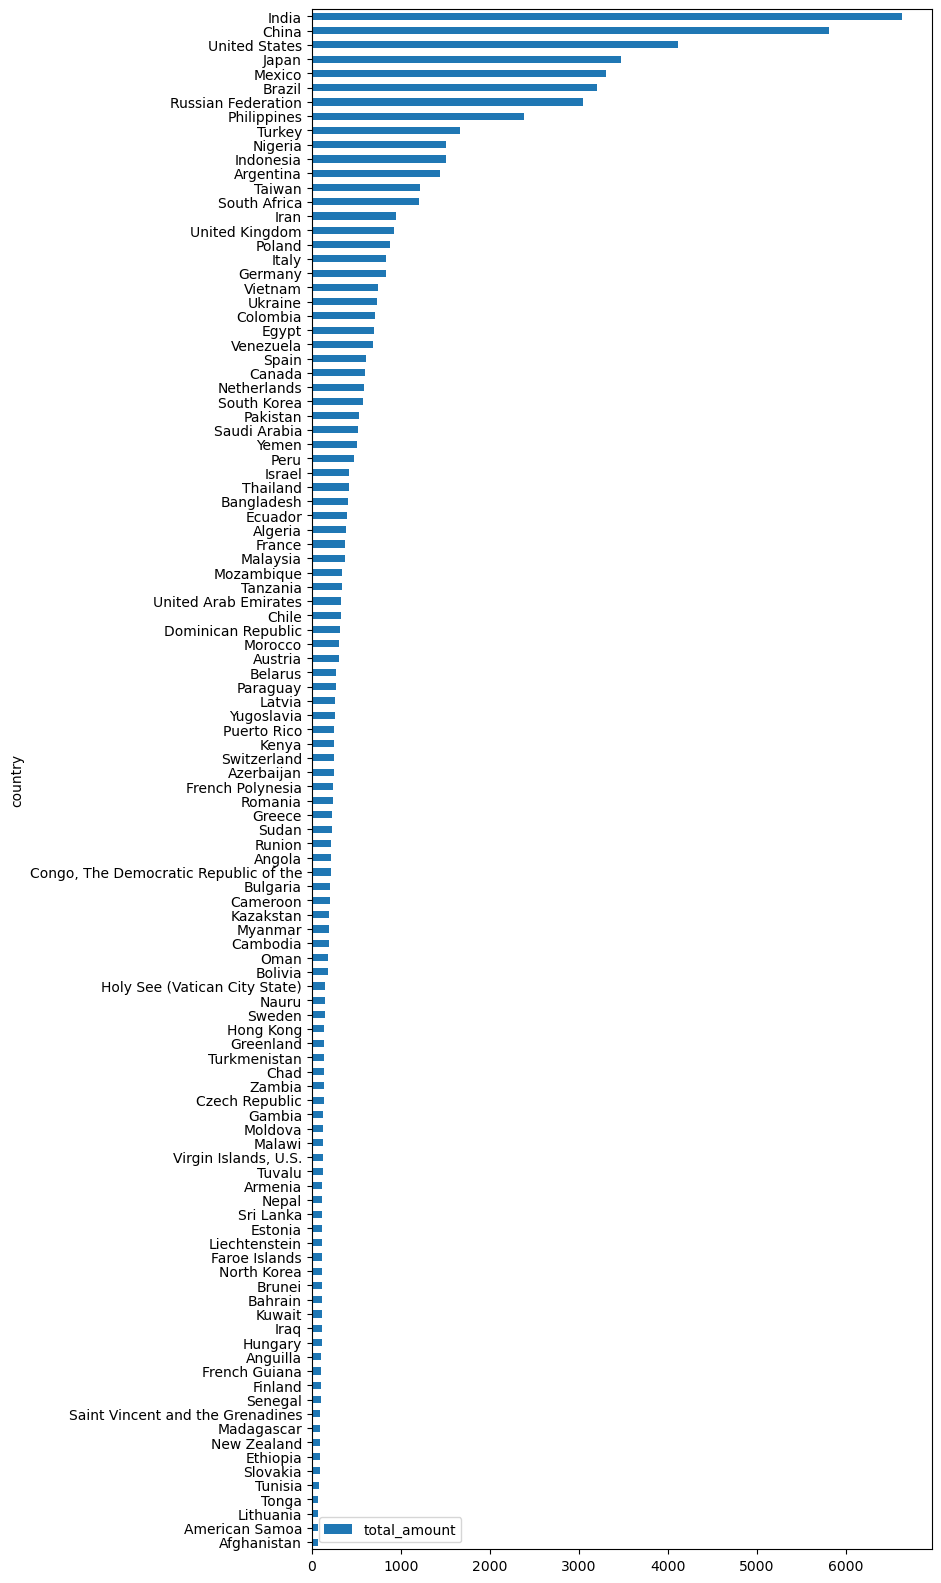

In [137]:
sales_per_country.plot.barh(x='country', y='total_amount', figsize=(8, 20));

We're given the list of EU countries to filter with. Run this cell first:

In [138]:
eu_countries = ['Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Czech Republic', 'Denmark', 'Estonia',
                'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Ireland', 'Italy', 'Latvia',
                'Lithuania', 'Luxembourg', 'Malta', 'Netherlands', 'Poland', 'Portugal', 'Romania',
                'Slovakia', 'Slovenia', 'Spain', 'Sweden']

### Exercise 8.9: Filter to the EU

We only care about EU countries. Use the provided `eu_countries` list to keep only EU rows. Call the result `sales_per_eu_country`.

> *Hint: `.isin(eu_countries)` is the same trick from Exercise 3.4.*

In [139]:
# Your turn. Write your solution here:


In [140]:
# Coach answer
sales_per_eu_country = sales_per_country[sales_per_country['country'].isin(eu_countries)]
sales_per_eu_country

,country,total_amount
2,Lithuania,73.76
5,Slovakia,89.74
11,Finland,101.74
14,Hungary,111.71
22,Estonia,115.70
31,Czech Republic,133.71
37,Sweden,144.66
46,Bulgaria,204.50
51,Greece,232.46
52,Romania,235.38


And the bar plot for EU countries only, **the answer to our first question**.

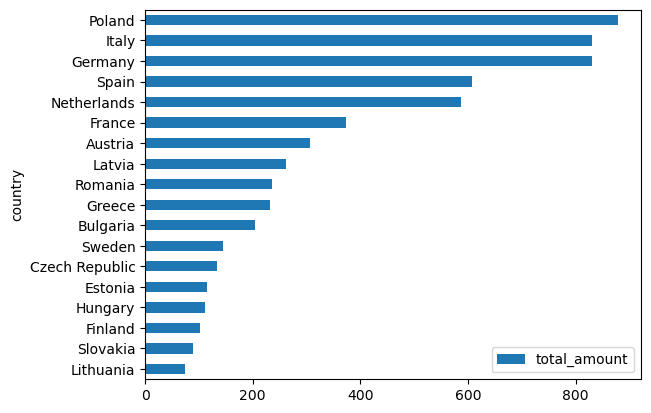

In [141]:
sales_per_eu_country.plot.barh(x='country', y='total_amount');

### Exercise 8.10: Export the result

Save `sales_per_eu_country` to a CSV called `eu_sales.csv` in the datasets folder.

In [142]:
# Your turn. Write your solution here:


In [143]:
# Coach answer
sales_per_eu_country.to_csv('../datasets/eu_sales.csv', index=False)

---
# Part 9: Who are the top-spending EU customers?
We now know which *countries* sell most. Let's drill down to *individual customers*.

### Exercise 9: Top 10 EU customers by spend

Starting from `customer_payment_full_details`, keep only customers in `eu_countries`, then show the **top 10 customers** by `total_amount`, including their name and country.

> *Hint: Filter with `.isin(eu_countries)`, then `sort_values(..., ascending=False).head(10)`.*

In [144]:
# Your turn. Write your solution here:


In [145]:
# Coach answer
eu_customers = customer_payment_full_details[
    customer_payment_full_details['country'].isin(eu_countries)
]
top_eu_customers = (
    eu_customers[['customer_id', 'first_name', 'last_name', 'country', 'total_amount']]
    .sort_values('total_amount', ascending=False)
    .head(10)
)
top_eu_customers

,customer_id,first_name,last_name,country,total_amount
136,137,RHONDA,KENNEDY,Netherlands,194.61
468,469,WESLEY,BULL,Spain,177.60
292,293,MAE,FLETCHER,Spain,158.69
195,196,ALMA,AUSTIN,Germany,151.65
438,439,ALEXANDER,FENNELL,Italy,151.64
308,309,CHRISTOPHER,GRECO,Italy,147.69
65,66,JANICE,WARD,Sweden,144.66
346,347,RYAN,SALISBURY,Latvia,142.70
113,114,GRACE,ELLIS,Germany,139.67
379,380,RUSSELL,BRINSON,Poland,136.64


<a name="anchorReading" style="position:absolute;"></a>
<hr style="border:2px solid">

# 13. Further Reading
<hr style="border-top:1px dashed">

### Tutorials
- [Automate the Boring Stuff with Python](https://automatetheboringstuff.com/) is an online (and paper!) book with basic Python tutorials and inspiration on what to do with Python.
- [Towards Data Science](https://towardsdatascience.com/) has articles about data science and data science tools, many of which rely on Python.
- [stack**overflow**](https://stackoverflow.com/questions/tagged/python) is a question and answer site for programming questions.
- [scipy lectures](http://scipy-lectures.org/) are a tutorial for using Python in Scientific computing, including data analysis

### Pandas information
- [Pandas cheatsheet](https://github.com/pandas-dev/pandas/blob/master/doc/cheatsheet/Pandas_Cheat_Sheet.pdf)
- [Pandas comparison with SQL](https://pandas.pydata.org/pandas-docs/stable/getting_started/comparison/comparison_with_sql.html)
- On Aptem, in the ***Python Videos*** component of the Learning plan overview, there is the ***Corndel Pandas Methods.zip***
